In [3]:
!pip install -q fiftyone

In [4]:
import fiftyone.zoo as foz
import os
import shutil
from tqdm import tqdm

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


In [5]:
categories = {
    "people": ["person"],
    "vehicles": ["car", "bus", "truck"],
    "animals": ["dog", "cat", "horse"],
    "objects": ["chair", "bottle", "cup"]
}

In [6]:
BASE_DIR = "/kaggle/working/coco_subset"

os.makedirs(BASE_DIR, exist_ok=True)

In [7]:
SAMPLES_PER_CATEGORY = 4000  # change this if needed

for category_name, class_list in categories.items():
    print(f"\nDownloading {category_name}...")

    dataset = foz.load_zoo_dataset(
        "coco-2017",
        split="train",
        classes=class_list,
        max_samples=SAMPLES_PER_CATEGORY,
        shuffle=True
    )

    save_dir = os.path.join(BASE_DIR, category_name)
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for sample in tqdm(dataset):
        src = sample.filepath
        dst = os.path.join(save_dir, f"{category_name}_{count}.jpg")

        try:
            shutil.copy(src, dst)
            count += 1
        except:
            continue

    print(f"Saved {count} images in {save_dir}")


 100% |██████|    1.9Gb/1.9Gb [2.5s elapsed, 0s remaining, 761.6Mb/s]      
Extracting annotations to '/root/fiftyone/coco-2017/raw/instances_train2017.json'
 100% |████████████████| 4000/4000 [4.0m elapsed, 0s remaining, 16.4 images/s]      
Writing annotations for 4000 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'train'
 100% |███████████████| 4000/4000 [23.2s elapsed, 0s remaining, 166.4 samples/s]      
Dataset 'coco-2017-train-4000' created


100%|██████████| 4000/4000 [00:12<00:00, 332.57it/s]

Saved 4000 images in /kaggle/working/coco_subset/people

Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


685 images found; downloading the remaining 3315
 100% |████████████████| 3315/3315 [3.3m elapsed, 0s remaining, 16.2 images/s]      
Writing annotations for 7315 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading existing dataset 'coco-2017-train-4000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


100%|██████████| 4000/4000 [00:11<00:00, 335.31it/s]

...

100%|██████████| 4000/4000 [00:11<00:00, 334.25it/s]

Saved 4000 images in /kaggle/working/coco_subset/animals

Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


1557 images found; downloading the remaining 2443
 100% |████████████████| 2443/2443 [2.4m elapsed, 0s remaining, 16.0 images/s]      
Writing annotations for 13252 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading existing dataset 'coco-2017-train-4000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


100%|██████████| 4000/4000 [00:11<00:00, 336.57it/s]

Saved 4000 images in /kaggle/working/coco_subset/objects


In [13]:
from IPython.display import FileLink
FileLink('/kaggle/working/coco_subset.zip')

/kaggle/working/coco_subset.zip

In [14]:
!zip -r coco_subset.zip /kaggle/working/coco_subset

  adding: kaggle/working/coco_subset/ (stored 0%)
  adding: kaggle/working/coco_subset/objects/ (stored 0%)
  adding: kaggle/working/coco_subset/objects/objects_3648.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_2563.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_1216.jpg (deflated 1%)
  adding: kaggle/working/coco_subset/objects/objects_3709.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_3445.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_679.jpg (deflated 1%)
  adding: kaggle/working/coco_subset/objects/objects_3141.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_1691.jpg (deflated 1%)
  adding: kaggle/working/coco_subset/objects/objects_2279.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_1984.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_1242.jpg (deflated 0%)
  adding: kaggle/working/coco_subset/objects/objects_73.j

In [1]:
coco_path = "/kaggle/input/datasets/anurajgogoi/coco-subset"

In [26]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*50)
    break

ROOT: /kaggle/input
DIRS: ['datasets']
FILES: []
--------------------------------------------------


In [2]:
places_path = "/kaggle/input/datasets/pankajkumar2002/places365"

In [3]:
import os
import cv2
import numpy as np
from torch.utils.data import Dataset

class CombinedDataset(Dataset):
    def __init__(self, coco_dir, places_dir):
        self.image_paths = []

        # Load COCO images
        for root, _, files in os.walk(coco_dir):
            for file in files:
                if file.endswith((".jpg", ".png")):
                    self.image_paths.append(os.path.join(root, file))

        # Load Places images
        for root, _, files in os.walk(places_dir):
            for file in files:
                if file.endswith((".jpg", ".png")):
                    self.image_paths.append(os.path.join(root, file))

        print(f"Total images loaded: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        img = cv2.imread(img_path)
        if img is None:
            return self.__getitem__((idx + 1) % len(self))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (256, 256))

        # Convert to LAB
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

        L = lab[:, :, 0] / 255.0
        ab = lab[:, :, 1:] / 128.0 - 1

        L = np.expand_dims(L, axis=0)
        ab = ab.transpose((2, 0, 1))

        return L.astype("float32"), ab.astype("float32")

In [4]:
dataset = CombinedDataset(
    coco_dir=coco_path,
    places_dir=places_path
)

Total images loaded: 52500


In [5]:
L, ab = dataset[0]

print(L.shape) 
print(ab.shape) 

(1, 256, 256)
(2, 256, 256)


In [5]:
from torch.utils.data import random_split

train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

**Model Training - AutoEncoder**

In [9]:
import torch
import torch.nn as nn

class ColorizationNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=2, padding=1),  # 128x128
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 64x64
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), # 32x32
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 2, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ColorizationNet().to(device)

criterion = nn.L1Loss()   # better than MSE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
from tqdm import tqdm

EPOCHS = 25

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for L, ab in tqdm(train_loader):
        L = L.to(device)
        ab = ab.to(device)

        pred_ab = model(L)

        loss = criterion(pred_ab, ab)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 1477/1477 [11:05<00:00,  2.22it/s]


Epoch 1, Loss: 0.0694


100%|██████████| 1477/1477 [06:34<00:00,  3.75it/s]


Epoch 2, Loss: 0.0688


100%|██████████| 1477/1477 [06:40<00:00,  3.69it/s]


...

Epoch 23, Loss: 0.0651


100%|██████████| 1477/1477 [07:31<00:00,  3.27it/s]


Epoch 24, Loss: 0.0649


100%|██████████| 1477/1477 [07:02<00:00,  3.50it/s]

Epoch 25, Loss: 0.0649


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import random

model.eval()

# 🔹 Pick random test image
idx = random.randint(0, len(test_dataset)-1)
L, ab = test_dataset[idx]

# 🔹 Prepare input
L_tensor = torch.tensor(L).unsqueeze(0).to(device)

# 🔹 Predict
with torch.no_grad():
    pred_ab = model(L_tensor).cpu().squeeze(0).numpy()

# -------------------------------
# 🔹 Reconstruct Ground Truth RGB
# -------------------------------
L_img = L[0] * 255

ab_gt = (ab + 1) * 128
ab_gt = ab_gt.transpose(1, 2, 0)

lab_gt = np.zeros((256, 256, 3))
lab_gt[:, :, 0] = L_img
lab_gt[:, :, 1:] = ab_gt

rgb_gt = cv2.cvtColor(lab_gt.astype("uint8"), cv2.COLOR_LAB2RGB)

# -------------------------------
# 🔹 Reconstruct Predicted RGB
# -------------------------------
ab_pred = (pred_ab + 1) * 128
ab_pred = ab_pred.transpose(1, 2, 0)

lab_pred = np.zeros((256, 256, 3))
lab_pred[:, :, 0] = L_img
lab_pred[:, :, 1:] = ab_pred

rgb_pred = cv2.cvtColor(lab_pred.astype("uint8"), cv2.COLOR_LAB2RGB)

# -------------------------------
# 🔹 Plot All Three
# -------------------------------
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(rgb_gt)
plt.title("Original (Ground Truth)")
plt.axis("off")

# Grayscale Input
plt.subplot(1,3,2)
plt.imshow(L[0], cmap='gray')
plt.title("Grayscale Input")
plt.axis("off")

# Colorized Output
plt.subplot(1,3,3)
plt.imshow(rgb_pred)
plt.title("Model Output")
plt.axis("off")

plt.show()

In [22]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
psnr_scores = []
ssim_scores = []

for L, ab in test_dataset:

    psnr_scores.append(psnr(rgb_gt, rgb_pred))
    ssim_scores.append(ssim(rgb_gt, rgb_pred, channel_axis=2))

print("Avg PSNR:", sum(psnr_scores)/len(psnr_scores))
print("Avg SSIM:", sum(ssim_scores)/len(ssim_scores))

Avg PSNR: 29.155628634046934
Avg SSIM: 0.958971487366746


In [24]:
torch.save(model.state_dict(), "autoencoder.pth")

**Model Training - UNet**

In [8]:
import torch
import torch.nn as nn

# 🔹 Basic block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Output
        self.final = nn.Conv2d(64, 2, kernel_size=1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        # Bottleneck
        b = self.bottleneck(self.pool3(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return self.tanh(out)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [11]:
from tqdm import tqdm

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for L, ab in tqdm(train_loader):
        L = L.to(device)
        ab = ab.to(device)

        pred_ab = model(L)
        loss = criterion(pred_ab, ab)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 2954/2954 [41:51<00:00,  1.18it/s]


Epoch 1, Loss: 0.0694


100%|██████████| 2954/2954 [38:55<00:00,  1.26it/s]


Epoch 2, Loss: 0.0678


100%|██████████| 2954/2954 [38:51<00:00,  1.27it/s]


...

Epoch 13, Loss: 0.0620


100%|██████████| 2954/2954 [39:57<00:00,  1.23it/s]


Epoch 14, Loss: 0.0616


100%|██████████| 2954/2954 [39:49<00:00,  1.24it/s]

Epoch 15, Loss: 0.0611


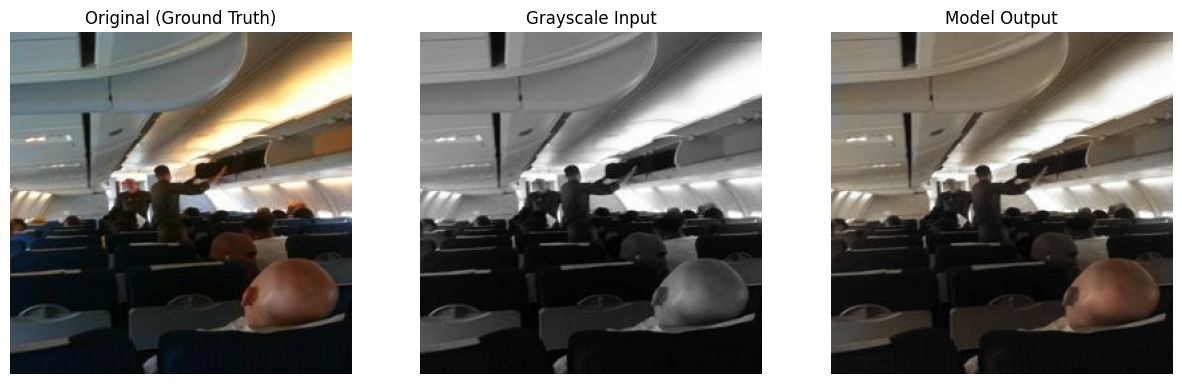

In [59]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import random

model.eval()

# random test image
idx = random.randint(0, len(test_dataset)-1)
L, ab = test_dataset[idx]

#  Prepare input
L_tensor = torch.tensor(L).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    pred_ab = model(L_tensor).cpu().squeeze(0).numpy()

# Reconstruct Ground Truth RGB

L_img = L[0] * 255

ab_gt = (ab + 1) * 128
ab_gt = ab_gt.transpose(1, 2, 0)

lab_gt = np.zeros((256, 256, 3))
lab_gt[:, :, 0] = L_img
lab_gt[:, :, 1:] = ab_gt

rgb_gt = cv2.cvtColor(lab_gt.astype("uint8"), cv2.COLOR_LAB2RGB)


# Reconstruct Predicted RGB

ab_pred = (pred_ab + 1) * 128
ab_pred = ab_pred.transpose(1, 2, 0)

lab_pred = np.zeros((256, 256, 3))
lab_pred[:, :, 0] = L_img
lab_pred[:, :, 1:] = ab_pred

rgb_pred = cv2.cvtColor(lab_pred.astype("uint8"), cv2.COLOR_LAB2RGB)

# -------------------------------
# 🔹 Plot All Three
# -------------------------------
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(rgb_gt)
plt.title("Original (Ground Truth)")
plt.axis("off")

# Grayscale Input
plt.subplot(1,3,2)
plt.imshow(L[0], cmap='gray')
plt.title("Grayscale Input")
plt.axis("off")

# Colorized Output
plt.subplot(1,3,3)
plt.imshow(rgb_pred)
plt.title("Model Output")
plt.axis("off")

plt.show()

In [26]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
psnr_scores = []
ssim_scores = []

for L, ab in test_dataset:

    psnr_scores.append(psnr(rgb_gt, rgb_pred))
    ssim_scores.append(ssim(rgb_gt, rgb_pred, channel_axis=2))

print("Avg PSNR:", sum(psnr_scores)/len(psnr_scores))
print("Avg SSIM:", sum(ssim_scores)/len(ssim_scores))

Avg PSNR: 20.842553898095506
Avg SSIM: 0.9153260878207711


In [58]:
torch.save(model.state_dict(), "unet.pth")

**Adding Perceptual loss**

In [7]:
!pip install -q kornia

In [8]:
import torch
import torch.nn as nn
import torchvision.models as models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.vgg = nn.Sequential(*list(vgg.children())[:16]).eval()

        for p in self.vgg.parameters():
            p.requires_grad = False

    def forward(self, pred, target):
        return nn.functional.l1_loss(self.vgg(pred), self.vgg(target))

In [9]:
import kornia.color as kc

def lab_to_rgb(L, ab):
    lab = torch.cat([L, ab], dim=1)   # (B,3,H,W)
    rgb = kc.lab_to_rgb(lab)          # range [0,1]
    return rgb

**ResNet Unet**

In [10]:
import torch
import torch.nn as nn
import torchvision.models as models

In [11]:
class ResNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        self.initial = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )  # (64, H/2, W/2)

        self.maxpool = resnet.maxpool  # (64, H/4, W/4)

        self.layer1 = resnet.layer1  # (64, H/4, W/4)
        self.layer2 = resnet.layer2  # (128, H/8, W/8)
        self.layer3 = resnet.layer3  # (256, H/16, W/16)
        self.layer4 = resnet.layer4  # (512, H/32, W/32)

    def forward(self, x):
        x0 = self.initial(x)
        x1 = self.maxpool(x0)

        x2 = self.layer1(x1)
        x3 = self.layer2(x2)
        x4 = self.layer3(x3)
        x5 = self.layer4(x4)

        return x0, x2, x3, x4, x5

In [12]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)
        
        # Fix size mismatch (important!)
        if x.shape != skip.shape:
            x = nn.functional.interpolate(x, size=skip.shape[2:])
        
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [13]:
class ResNetUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = ResNetEncoder()

        self.up4 = UpBlock(512, 256, 256)
        self.up3 = UpBlock(256, 128, 128)
        self.up2 = UpBlock(128, 64, 64)
        self.up1 = UpBlock(64, 64, 64)

        self.final = nn.Conv2d(64, 2, kernel_size=1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        # Convert grayscale (1 channel) → 3 channels
        x = x.repeat(1, 3, 1, 1)

        x0, x2, x3, x4, x5 = self.encoder(x)

        d4 = self.up4(x5, x4)
        d3 = self.up3(d4, x3)
        d2 = self.up2(d3, x2)
        d1 = self.up1(d2, x0)

        out = self.final(d1)
        return self.tanh(out)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetUNet().to(device)

l1_loss = nn.L1Loss()
perc_loss = VGGPerceptualLoss().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

lambda_perc = 0.1

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s] 


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 210MB/s]  


In [18]:
from tqdm import tqdm
import torch.nn.functional as F

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for L, ab in tqdm(train_loader):
        L = L.to(device)
        ab = ab.to(device)

        # Forward
        pred_ab = model(L)

        pred_ab = F.interpolate(pred_ab, size=ab.shape[2:], mode='bilinear', align_corners=False)

        # L1 loss
        loss_l1 = l1_loss(pred_ab, ab)

        # Convert to RGB
        pred_rgb = lab_to_rgb(L, pred_ab)
        gt_rgb = lab_to_rgb(L, ab)

        # Perceptual loss
        loss_perc = perc_loss(pred_rgb, gt_rgb)

        # Total loss
        loss = loss_l1 + lambda_perc * loss_perc

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 5907/5907 [37:31<00:00,  2.62it/s]  


Epoch 1, Loss: 0.0656


100%|██████████| 5907/5907 [31:07<00:00,  3.16it/s]


Epoch 2, Loss: 0.0631


100%|██████████| 5907/5907 [30:39<00:00,  3.21it/s]


...

Epoch 18, Loss: 0.0446


100%|██████████| 5907/5907 [30:43<00:00,  3.20it/s]


Epoch 19, Loss: 0.0436


100%|██████████| 5907/5907 [30:43<00:00,  3.20it/s] 

Epoch 20, Loss: 0.0426


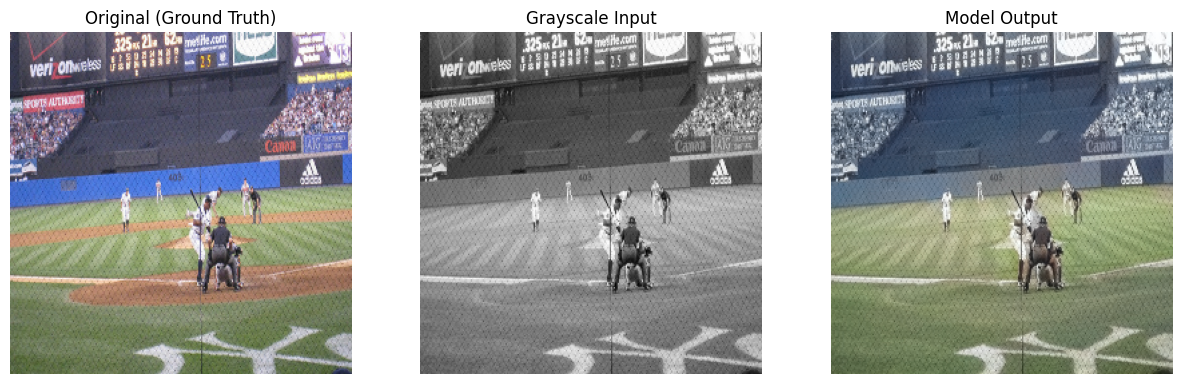

In [62]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import random
import torch.nn.functional as F

model.eval()

# random test image
idx = random.randint(0, len(test_dataset)-1)
L, ab = test_dataset[idx]

# Prepare input
L_tensor = torch.tensor(L).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    pred_ab = model(L_tensor)

    pred_ab = F.interpolate(
        pred_ab,
        size=L_tensor.shape[2:],  # (H, W)
        mode='bilinear',
        align_corners=False
    )

    pred_ab = pred_ab.cpu().squeeze(0).numpy()


# Reconstruct Ground Truth RGB

L_img = (L[0] * 255).astype("uint8")
h, w = L_img.shape

ab_gt = (ab + 1) * 128
ab_gt = ab_gt.transpose(1, 2, 0)

lab_gt = np.zeros((h, w, 3), dtype="uint8")
lab_gt[:, :, 0] = L_img
lab_gt[:, :, 1:] = ab_gt.astype("uint8")

rgb_gt = cv2.cvtColor(lab_gt, cv2.COLOR_LAB2RGB)


# Reconstruct Predicted RGB

ab_pred = (pred_ab + 1) * 128
ab_pred = ab_pred.transpose(1, 2, 0)

lab_pred = np.zeros((h, w, 3), dtype="uint8")
lab_pred[:, :, 0] = L_img
lab_pred[:, :, 1:] = ab_pred.astype("uint8")

rgb_pred = cv2.cvtColor(lab_pred, cv2.COLOR_LAB2RGB)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(rgb_gt)
plt.title("Original (Ground Truth)")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(L[0], cmap='gray')
plt.title("Grayscale Input")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(rgb_pred)
plt.title("Model Output")
plt.axis("off")

plt.show()

In [46]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
psnr_scores = []
ssim_scores = []

for L, ab in test_dataset:

    psnr_scores.append(psnr(rgb_gt, rgb_pred))
    ssim_scores.append(ssim(rgb_gt, rgb_pred, channel_axis=2))

print("Avg PSNR:", sum(psnr_scores)/len(psnr_scores))
print("Avg SSIM:", sum(ssim_scores)/len(ssim_scores))

Avg PSNR: 31.328941123199268
Avg SSIM: 0.9832189711097261


In [48]:
torch.save(model.state_dict(), "resnet_unet.pth")